In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([300, 300]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/train/warrior2'
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/test/warrior2'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset1 = data1+data2+data3+data4+data5+data6+data7+data8
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1) 

In [3]:
'''骨架坐标点数据集载入'''
import torch
import pandas as pd
import numpy as np
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/warrior2_train_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#print(df)
dataset_train = df.values
dataset_train = np.array(dataset_train)
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/warrior2_test_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test, Y_test)
trainset2_data =  torch.utils.data.TensorDataset(X_train,Y_train)
trainset2 = trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)


In [4]:
'''训练集合并'''
import numpy as np
import torch.utils.data as data
list_x_train = []
list_y_train = []
for i in range(len(trainset1)):
  set1 = torch.flatten(trainset1[i][0])
  set = torch.cat([set1, trainset2[i][0]],0)
  list_x_train.append(set)
  list_y_train.append(trainset1[i][1])
x_train = np.array(list_x_train)
y_train = np.array(list_y_train)
print(x_train)
print(y_train)
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = Mydataset(x_train,y_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

[tensor([ -0.6941,  -0.6706,  -0.6549,  ..., 350.7368, 628.1818, -36.2704])
 tensor([   1.0000,    1.0000,    1.0000,  ...,  147.4123,  795.5460,
         -118.5728])
 tensor([ 8.1961e-01,  8.9020e-01,  9.2941e-01,  ...,  3.6839e+02,
          1.4564e+03, -5.5821e+01])                                ...
 tensor([9.0196e-02, 9.8039e-02, 1.1373e-01,  ..., 1.4260e+03, 1.1600e+03,
         3.2150e+02])
 tensor([ -1.0000,  -1.0000,  -1.0000,  ..., 356.2167, 610.1401, -22.8651])
 tensor([ 4.7451e-01,  4.7451e-01,  4.6667e-01,  ...,  3.0999e+02,
          9.9238e+02, -1.6680e+02])                               ]
[0 0 0 ... 1 1 1]


<ipython-input-4-3d8bbbd1a5d6>:11: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  x_train = np.array(list_x_train)
<ipython-input-4-3d8bbbd1a5d6>:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_train = np.array(list_x_train)


In [5]:
torch.save(trainset,"/content/drive/MyDrive/yoga/datasets/eva_warrior22_trainset.pt" )

In [6]:
'''测试集合并'''
import numpy as np
import torch.utils.data as data
list_x_test = []
list_y_test = []
for i in range(len(testset1)):
  set1 = torch.flatten(testset1[i][0])
  set = torch.cat([set1, testset2[i][0]],0)
  list_x_test.append(set)
  list_y_test.append(testset1[i][1])
x_test = np.array(list_x_test)
y_test = np.array(list_y_test)
testset = Mydataset(x_test,y_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

<ipython-input-6-eda196c4da7c>:11: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  x_test = np.array(list_x_test)
<ipython-input-6-eda196c4da7c>:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_test = np.array(list_x_test)


In [7]:
torch.save(testset,"/content/drive/MyDrive/yoga/datasets/eva_warrior22_testset.pt" )

In [8]:
import torch.utils.data as data
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_warrior22_trainset.pt")
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

In [9]:
testset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_warrior22_testset.pt")
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

In [10]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out

In [11]:
'''VGG19与MLP网络全连接层拼接网络'''
import torch.nn as nn
import torchvision.models as models
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier = nn.Sequential(*list(vgg19.classifier.children())[:-1])  
mlp_pre = torch.load('/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior2_contrast2.pkl')
mlp_pre.all =nn.Sequential(*list(mlp_pre.all.children())[:-1])
class fusionnet(nn.Module):
    def __init__(self, num_class=2):
        super().__init__()
        self.vgg = vgg19
        self.mlp = mlp_pre
        self.fc_out = nn.Linear(67 + 4096, num_class)
    def forward(self, x):
        #print(x.size())
        x1 = x[..., :128*128*3]
        x1 = torch.reshape(x1, (-1,3,128,128))
        #print(x1.shape)
        x2 = x[..., 128*128*3:]
        #print(x2.shape)
        x1 = self.vgg(x1)
        x2 = self.mlp(x2)
        #print(x1.shape)
        #print(x2.shape)
        out = torch.concat([x1,x2], 1)
        output = self.fc_out(out)
        return output

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|          | 0.00/548M [00:00<?, ?B/s]

In [12]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/warrior2/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/warrior2/testloss2.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [13]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/warrior2/trainloss2.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/warrior2/testloss2.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/warrior2/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/warrior2/testloss2.csv',index=False)

In [14]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
test(fusionnet().to(device))

测试集精度为：53%
测试集中不标准动作图片的预测精度为：48%
测试集中标准动作图片的预测精度为：60%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     17   18
1.0     10   15


[1,  100] loss:3.837
[1,  200] loss:3.278
Test set: Average loss: 0.7676
[2,  100] loss:2.324
[2,  200] loss:2.481
Test set: Average loss: 0.7992
[3,  100] loss:2.530
[3,  200] loss:2.484
Test set: Average loss: 0.7253
[4,  100] loss:2.237
[4,  200] loss:2.053
Test set: Average loss: 0.8651
[5,  100] loss:2.193
[5,  200] loss:2.096
Test set: Average loss: 0.7595
[6,  100] loss:2.171
[6,  200] loss:2.027
Test set: Average loss: 0.8951
[7,  100] loss:1.707
[7,  200] loss:2.103
Test set: Average loss: 0.6881
[8,  100] loss:1.858
[8,  200] loss:1.764
Test set: Average loss: 0.7486
[9,  100] loss:1.877
[9,  200] loss:1.745
Test set: Average loss: 0.8053
[10,  100] loss:1.771
[10,  200] loss:1.753
Test set: Average loss: 0.9610
[11,  100] loss:1.655
[11,  200] loss:1.641
Test set: Average loss: 0.6707
[12,  100] loss:1.645
[12,  200] loss:1.638
Test set: Average loss: 0.7539
[13,  100] loss:1.558
[13,  200] loss:1.538
Test set: Average loss: 0.9785
[14,  100] loss:1.533
[14,  200] loss:1.691

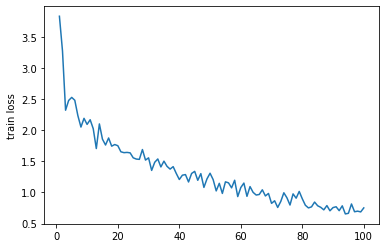

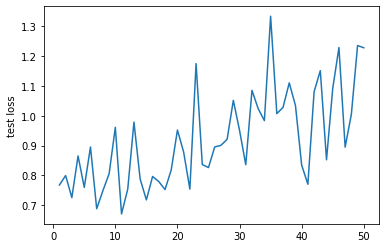

Finished Training


In [15]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(fusionnet().to(device),50,100)

[1,  100] loss:0.628
[1,  200] loss:0.753
Test set: Average loss: 1.3178
[2,  100] loss:0.591
[2,  200] loss:0.696
Test set: Average loss: 0.8001
[3,  100] loss:0.588
[3,  200] loss:0.651
Test set: Average loss: 1.0791
[4,  100] loss:0.601
[4,  200] loss:0.566
Test set: Average loss: 1.2229
[5,  100] loss:0.570
[5,  200] loss:0.697
Test set: Average loss: 0.9431
[6,  100] loss:0.605
[6,  200] loss:0.596
Test set: Average loss: 1.3450
[7,  100] loss:0.528
[7,  200] loss:0.651
Test set: Average loss: 1.3476
[8,  100] loss:0.575
[8,  200] loss:0.746
Test set: Average loss: 1.2071
[9,  100] loss:0.585
[9,  200] loss:0.585
Test set: Average loss: 1.0420
[10,  100] loss:0.618
[10,  200] loss:0.738
Test set: Average loss: 1.0972
[11,  100] loss:0.518
[11,  200] loss:0.511
Test set: Average loss: 1.2197
[12,  100] loss:0.539
[12,  200] loss:0.406
Test set: Average loss: 1.3741
[13,  100] loss:0.453
[13,  200] loss:0.503
Test set: Average loss: 1.0377
[14,  100] loss:0.427
[14,  200] loss:0.546

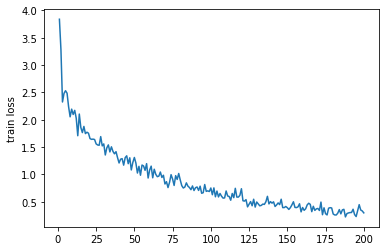

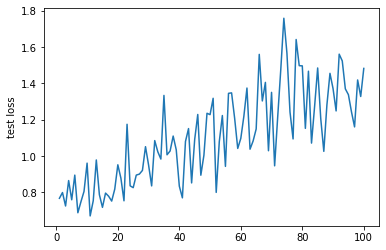

Finished Training


In [16]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.303
[1,  200] loss:0.284
Test set: Average loss: 1.5833
[2,  100] loss:0.290
[2,  200] loss:0.325
Test set: Average loss: 1.3083
[3,  100] loss:0.272
[3,  200] loss:0.425
Test set: Average loss: 1.3196
[4,  100] loss:0.215
[4,  200] loss:0.240
Test set: Average loss: 1.3529
[5,  100] loss:0.239
[5,  200] loss:0.239
Test set: Average loss: 1.3535
[6,  100] loss:0.349
[6,  200] loss:0.314
Test set: Average loss: 1.3405
[7,  100] loss:0.184
[7,  200] loss:0.241
Test set: Average loss: 1.5549
[8,  100] loss:0.303
[8,  200] loss:0.228
Test set: Average loss: 1.0786
[9,  100] loss:0.256
[9,  200] loss:0.253
Test set: Average loss: 1.6621
[10,  100] loss:0.262
[10,  200] loss:0.323
Test set: Average loss: 1.3354
[11,  100] loss:0.228
[11,  200] loss:0.283
Test set: Average loss: 1.5585
[12,  100] loss:0.240
[12,  200] loss:0.252
Test set: Average loss: 1.6258
[13,  100] loss:0.213
[13,  200] loss:0.231
Test set: Average loss: 1.6206
[14,  100] loss:0.279
[14,  200] loss:0.273

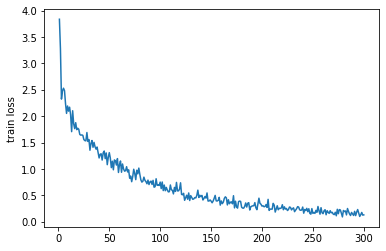

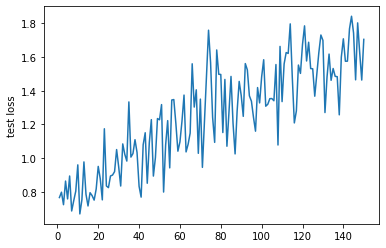

Finished Training


In [17]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.177
[1,  200] loss:0.126
Test set: Average loss: 1.4757
[2,  100] loss:0.242
[2,  200] loss:0.156
Test set: Average loss: 2.0941
[3,  100] loss:0.093
[3,  200] loss:0.140
Test set: Average loss: 1.9869
[4,  100] loss:0.194
[4,  200] loss:0.188
Test set: Average loss: 1.6813
[5,  100] loss:0.205
[5,  200] loss:0.113
Test set: Average loss: 1.6026
[6,  100] loss:0.105
[6,  200] loss:0.168
Test set: Average loss: 1.8745
[7,  100] loss:0.147
[7,  200] loss:0.096
Test set: Average loss: 1.4875
[8,  100] loss:0.134
[8,  200] loss:0.171
Test set: Average loss: 1.7042
[9,  100] loss:0.143
[9,  200] loss:0.112
Test set: Average loss: 1.7817
[10,  100] loss:0.185
[10,  200] loss:0.139
Test set: Average loss: 1.6620
[11,  100] loss:0.175
[11,  200] loss:0.113
Test set: Average loss: 1.7269
[12,  100] loss:0.090
[12,  200] loss:0.079
Test set: Average loss: 1.6150
[13,  100] loss:0.142
[13,  200] loss:0.137
Test set: Average loss: 1.6895
[14,  100] loss:0.121
[14,  200] loss:0.109

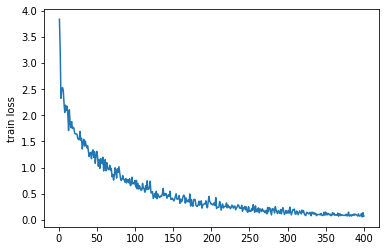

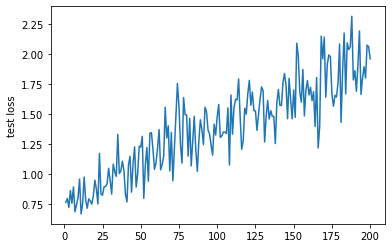

Finished Training


In [22]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
train_test2(model.to(device),50,100)

In [23]:
#训练200个epoch的测试精度
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/warrior2/YogaEvaNet_warrior22.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：73%
测试集中不标准动作图片的预测精度为：74%
测试集中标准动作图片的预测精度为：72%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     26    9
1.0      7   18
